# Redes neurais em problemas de classificação

## Material introdutório

###### Notebook por Ana Carolina Sayumi I. Alves

## Introdução

### Os problemas de classificação

Para falar de problemas de classificação precisamos antes relembrar dos dois tipos de variáveis com as quais trabalhamos, seja em machine learning ou estatística: variáveis _numéricas_ e _categóricas_. Variáveis numéricas são, como o nome sugere, aquelas que armazenam dados numéricos, sejam eles discretos ou não. Já variáveis categóricas são aquelas que armazenam rótulos, categorias ou atributos, podendo haver ordem ou não. Quando atacamos um problema cujo target é **categórico** estamos lidando com um **problema de classificação**. 

Os problemas de classificação podem ser divididos em dois tipos: _binário_ e _multiclasse_.

*Antes de nos aprofundarmos em cada caso, segue abaixo um esquema simplificado das variáveis e seus problemas relacionados.

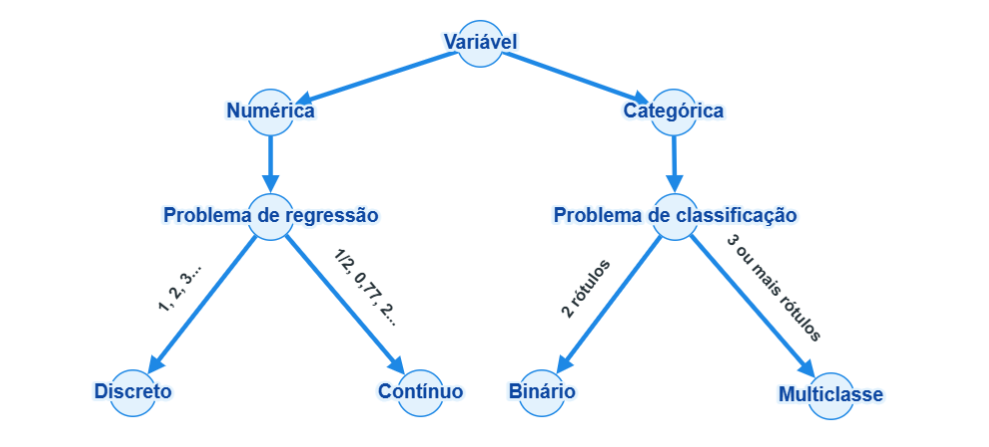


#### Classificação binária x multiclasse

##### Binária

Os problemas de classificação **binária** são aqueles que apresentam _dois diferentes rótulos_ em seu target, como o próprio nome sugere. 

Para consolidar essa ideia, suponha que temos os seguintes dados

|   Nome  | Horas de sono | Acorda durante a noite? | Qualidade de sono |
|:-------:|:-------------:|-------------------------|:----------:|
|  Alice  |       7       |           Sim           |    Baixa   |
| Beatriz |       6       |           Não           |    Média   |
|  Carla  |       9       |           Não           |    Alta    |
|   Dani  |       8       |           Sim           |    Média   |

E queremos atacar o problema de cordar durante a noite, ou seja, nossa variável "Acorda durante a noite?". Nesse cenário, para cada novo indivíduo sendo avaliado, há duas possíveis categorias para atribir a ele: "Sim", caso ele acorde durante a noite, ou "Não", caso não o faça.

Esse é um exemplo simples de problema de classificação binária: nosso modelo pode prever apenas duas diferentes categorias, nesse caso, "Sim" ou "Não".

##### Multiclasse

Quando há _mais de duas categorias_ no target do problema que estamos atacando, chamamos o problema de **multiclasse**. Um exemplo clássico de atributos para target multiclasse são "Baixo", "Médio" e "Alto". Aproveitando o exemplo passado, podemos supor que agora queremos olhar para a qualidade de sono, e não mais para as interrupções do sono. Para esse caso, podemos atribuir 3 diferentes rótulos para cada novo exemplo sendo avaliado: "Baixa", "Média" e "Alta", e nosso problema passa a ser de classificação multiclasse.

### E porque olhar para a classificação?

Muitos dos problemas que resolvemos diariamente com nossas redes neurais biológicas são de classificação: "Qual a cor daquele objeto?", "Qual letra é aquela?", "Qual número está escrito?", "Quem é aquela pessoa?" e por aí vai... De modo similar, na ciência muitos problemas com os quais lidamos diariamente são de classificação, desde a previsão de propriedades de materiais até a identificação de biomarcadores para câncer.

## MLP classificadora - diferenças em relação a problemas de regressão

Antes de prontamente fazermos o código, vamos olhar para as principais diferenças entre uma rede neural regressora, uma classificadora binária e uma classificadora multiclasse. 

### Regressora x Classificadora

A primeira grande diferença que devemos pontuar é a função de perda utilizada para MLPs classificadoras. Enquanto gerealmente utilizamos RMSE (Root Mean Squared Error) para problemas de regressão, para problemas de classificação geralmente utiliza-se a função **Cross-Entropy Loss**. E por que fazemos isso? Porque, quando falamos de MLPs para classificação, estamos tratando de redes neurais que retornam valores representativos de probabilidades de um resultado, não valores do próprio resultado, como em uma regressora [1], [2].

Isso nos leva à segunda e principal diferença: uma MLP classificadora deve retornar valores de $0$ a $1$ referentes à probabilidade de seu exemplo corresponder aos possíveis rótulos. Como assim? Significa que o modelo irá prever uma probabilidade para cada umas das possíveis classes fornecidas, para um problema multiclasse, ou irá prever uma única probabilidade, para um problema binário. As diferenças serão melhor discutidas mais a frente. 

E como se faz para garantir que o valor de saída de nossa rede corresponda _de fato_ à uma probabilidade? Isso pode ser feito aplicando funções específicas em nossa camada de saída, computando nossa terceira e última grande diferença entre MLPs regressoras e classificadoras. 

Para a camada de saída de classificadores binários, pode-se usar a função sigmoide [3]

![Sigmoide](https://thomaslam.github.io/images/sigmoid.png)

E para a camada de saída de classificadores binários, pode-se usar a função **Softmax**. Essa função garante que todos os valores de saída estarão entre $0$ e $1$ e que, se somados, resultem em $1$ [3], [4], [5].

![Softmax](https://images.contentstack.io/v3/assets/bltac01ee6daa3a1e14/blte5e1674e3883fab3/65ef8ba4039fdd4df8335b7c/img_blog_image1_inline_(2).png?width=768&disable=upscale&auto=webp)

Sumarizando, temos então como diferenças entre uma MLP regressora e uma MLP classificadora:
- Função de perda
- Natureza dos valores de saída e
- Função aplicada à camada de saída

### Binária x Multiclasse

Agora, entrando em detalhes, temos as diferenças entre as MLPs para problemas binários e para problemas multiclasse. A principal diferença aqui aparece na saída da MLP e na função de perda utilizada para computar o desempenho.


#### Saída

A grande diferença entre as saídas é: 

Uma MLP de classificação **binária** irá retornar, para cada instância, **um único valor de probabilidade**. Isso acontece porque em problemas de classificação o target passa por um _encoding_, para que consiga ser processado pela rede neural, e, em uma classificação binária, temos apenas dois rótulos: $1$ ou $0$. Assim, pode-se avaliar apenas se o valor previsto está próximo ou não do valor original e por essa razão a função da camada de saída pode ser a _função sigmoide_. Ademais, para converter a saída em uma classe novamente, basta observar se o valor é maior ou menor que $0.5$: se for maior, atribui-se o rótulo $1$, se for menor, atribui-se o rótulo $0$. 

Já para uma MLP de classificação **multiclasse** irá retornar, como visto acima, **um valor de probabilidade para cada possível rótulo**. Aqui, o target passa por _encoding_ de modo que temos um vetor de tamanho `len(set(target))`, ou seja, de tamanho igual ao número $n$ de categorias $C$ presentes no target. Dessa forma, a saída para cada instância será também um vetor computando as probabilidades daquela amostra apresentar o rótulo $C_1$, $C_2$, $C_3$... até $C_n$, por isso usa-se a _função softmax_ para a camada de saída. Diferente da conversão de saída da classificação binária, no caso da multiclasse atribui-se à instância a categoria correspondente à maior probabilidade apresentada. Recuperando a imagem da função softmax como exemplo

![Softmax](https://images.contentstack.io/v3/assets/bltac01ee6daa3a1e14/blte5e1674e3883fab3/65ef8ba4039fdd4df8335b7c/img_blog_image1_inline_(2).png?width=768&disable=upscale&auto=webp)

O rótulo que seria atribuído à essa observação seria aquele correspondente à porcentagem de $90\%$, ou seja, o segundo.

#### Função de perda

Dadas as diferentes saídas, temos então duas funções para avaliar o desempenho da previsão: **Categorical Cross Entropy** para multiclasse e **Binary Cross Entropy** para binário [2]. 

Começando pela **Binary Cross Entropy**, a função é a seguinte[6]:

$$
BCE = -\frac{1}{N} \sum_{i=1}^{N} (y_ilog(p_i)+(1-y_i)log(1-p_i))
$$

onde

$N =$ número de amostras

$y_i=$ categoria verdadeira de $i$ ($0$ ou $1$)

$p_i=$ probabilidade atribuída à $i$

Olhando apenas para o que temos dentro do somatório, caso $y_i = 0$ resta apenas o termo $log(1-p_i)$ e quanto maior for o valor previsto, maior o valor de erro e mais distante ele estará da categoria verdadeira. Agora caso $y_i = 1$, resta apenas $log(p_i)$ e, de modo semelhante, quanto menor for o valor previsto, maior o valor de erro e mais distante de $1$. Como, depois de somar todas essas perdas por observação, há a divisão pelo número de amostras multiplicado por $-1$, essa função é capaz de computar o módulo da _perda média_ das previsões. Ou seja, quanto menor a perda, melhor o desempenho do modelo.


Agora olhando para a **Categorical Cross Entropy** temos a seguinte função [7]:

$$
L(y, \^y) = - \sum_{i=1}^{C} y_ilog(\^y_i)
$$

onde

$L(y, \^y) =$ Categorical Cross Entropy

$C =$ número de classes

$y_i=$ categoria verdadeira de $i$

$\^y_i=$ probabilidade atribuída à classe $i$

Olhando um pouco para as informações que a matemática pode nos fornecer, vejamos o lado de dentro do somatório: $y_ilog(\^y_i)$. Aqui temos o vetor que representa a categoria correta ($[0, 0, 1, 0]$, por exemplo) multiplicado pelo logaritmo aplicado ao vetor de probabilidades ($[0.2, 0.1, 0.75, 0.05]$, por exemplo). Isso mostra que a perda será, basicamente, $-log($ probabilidade atribuída à categoria correta $)$, ou seja, será em função da _confiança_ da previsão correta.

Assim como a Binary Cross Entropy, essa função deve ser minimizada.

## Métricas para avaliar classificadores

### Partindo do começo...

Como vimos anteriormente, não podemos utilizar funções como MSE ou RMSE para computar o desempenho do modelo, entretanto, as funções de _Cross Entropy_ também não são as métricas utilizadas, então, como avaliamos classificadores?

De modo muito similar ao que é feito para outros algoritmos de machine learning, podemos computar a acurácia, sensibilidade, F1-score, precisão, etc. do modelo treinado para inferir seu desempenho. Abaixo iremos explorar um pouco melhor o que cada uma dessas métricas significa e como são calculadas.

### E porque não a função de perda?

As funções de _Cross Entropy_ são utilizadas, como a própria pergunta sugere, geralmente para minimizar a perda do modelo por ajuste em seus parâmetros (pesos e viéses), por não esclarecem de modo tão claro ao leitor se a classificação de fato - o ato de atribuir categorias às observações - foi feita de forma satisfatória, como fazem as métricas padrão citadas acima.

Isso significa que ela não pode ser usada? Não, as funções de perda até poderiam ser utilizadas, mas não é o comum na literatura [8].

### Matrizes de confusão

Para computar as estatísticas, primeiro construímos a matriz de confusão. Uma matriz de confusão vai computar os verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos de um problema. Para problemas binários, a matriz de confusão irá seguir a seguinte estrutura:

|                      |Valor predito = 1|Valor predito = 0|
|:--------------------:|:---------------:|:---------------:|
| <b>Valor real = 1</b>|      VP         |FN|
| <b>Valor real = 0</b>|      FP         |VN|

Sendo:

-   **VP** = Verdadeiro positivo: rótulo real é 1 e a previsão foi 1.
-   **FP** = Falso positivo: rótulo real é 0 e a previsão foi 1.
-   **VN** = Verdadeiro negativo: rótulo real é 0 e a previsão foi 0.
-   **FN** = Falso negativo: rótulo real é 1 e a previsão foi 0.

Para problemas multiclasse, a estrutura se apresenta da seguinte forma:

|                      |Valor predito = 0|Valor predito = 1|Valor predito = 2|...|Valor predito = C|
|:--------------------:|:---------------:|:---------------:|:---------------:|:-:|:-:|
| <b>Valor real = 0</b>|<font color="green"> real=0/previsto=0 <font>|<font color="yellow">real=0/previsto=1<font>|<font color="yellow"> real=0/previsto=2<font>|<font color="yellow"> ...<font>|<font color="yellow"> real=0/previsto=C<font>|
| <b>Valor real = 1</b>|<font color="orange">real=1/previsto=0<font>|<font color="green">real=1/previsto=1 <font>|<font color="red"> real=1/previsto=2<font>|<font color="red"> ...<font>|<font color="red"> real=1/previsto=C<font>|
| <b>Valor real = 2</b>|<font color="orange">real=2/previsto=0<font>|<font color="red"> real=2/previsto=1<font>|<font color="green"> real=2/previsto=2 <font>|<font color="red"> ...<font>|<font color="red"> real=2/previsto=C<font>|
|...|<font color="orange">...</font>|<font color="red"> ...<font>|<font color="red"> ...<font>|<font color="green"> ...<font>|<font color="red"> ...<font>|
| <b>Valor real = C</b>|<font color="orange">real=C/previsto=0<font>|<font color="red"> real=C/previsto=1<font>|<font color="red"> real=C/previsto=2<font>|<font color="red"> ...<font>|<font color="green"> real=C/previsto=C <font>|

Sendo na forma $C\times C$, onde $C$ é o número de classes do seu problema. A partir dessa, podemos extrair, para cada classe, uma matriz de confusão similar à binária, colocando o rótulo escolhido contra todos os outros, da seguinte forma:

| |Valor predito = 0|Valor predito &ne; 0|
|:-:|:-:|:-:|
| <b>Valor real = 0</b>|VP|FN|
| <b>Valor real &ne; 0</b>|FP|VN|

Ou seja, agora FP, FN e VN serão

- **FP** = soma de todas as observações diferentes do rótulo escolhido às quais foi atribuído o rótulo escolhido (no caso de nossa matriz multiclasse, seria a soma de tudo em <font color=orange>laranja</font>) 
- **FN** = soma de todas as observações iguais ao rótulo escolhido mas às quais foram atribuídos outros rótulos (ou a soma de tudo em <font color=yellow>amarelo</font>)
- **VN** = soma de todas as observações diferentes do rótulo escolhido às quais foram atribuídos rótulos diferentes do escolhido (ou a soma de tudo em <font color=red>vermelho</font>)

VP serão apenas os verdadeiros positivos da classe sendo analisada. Todos os outros verdadeiros positivos são ignorados para essa análise.

A partir desses valores, podemos computar as métricas de desempenho.

### Estatísticas possíveis

Seguem abaixo as métricas que podemos obter uma vez que temos os valores de VP, FP, VN e FN, como calculá-las e qual informação podemos obter a partir delas [8], [10].

#### A partir de matrizes $2\times2$

##### Acurácia

$$
\mathrm{ACC = \frac{VP + VN}{VP + FP + VN + FN}}
$$

A acurácia mede qual a fração de exemplos que foram classificados da maneira correta. Em dados balanceados, é uma boa métrica, mas no caso de dados desbalanceados, pode ser enganosa.

##### Sensibilidade ou _recall_

$$
\mathrm{TPR = \frac{VP}{VP + FN}}
$$

O recall computa quantos exemplos que possuem o rótulo positivo foram identificados corretamente. Em geral é analisado em conjunto com a Especificidade.

##### Especificidade

$$
\mathrm{TNR = \frac{VN}{VN + FP}}
$$

A especificidade computa quantos exemplos que possuem o rótulo negativo foram identificados corretamente. Em geral é analisado em conjunto com o recall.

##### Precisão

$$
\mathrm{PPV = \frac{VP}{VP + FP}}
$$

A precisão computa, dos exemplos identificados como positivos, quantos realmente são positivos. Geralmente é analisada em conjunto com o Valor predito negativo.

##### Valor predito negativo

$$
\mathrm{NPV = \frac{VN}{VN + FN}}
$$

O valor predito negativo computa, dos exemplos identificados como negativos, quantos realmente são negativos. Geralmente é analisado em conjunto com a Precisão.

##### F1-score

$$
\mathrm{F1 = \frac{2}{\frac{1}{Recall} + \frac{1}{Precisão}} = \frac{2VP}{2VP + FP + FN}}
$$

O F1-score mede a média harmônica entre recall e precisão, considerando assim os verdadeiros e falsos positivos em relação às instâncias que deveriam ser identificadas positivas ou foram identificadas erroneamente.

##### Índice de Youden

$$
\mathrm{Youden = Recall + Especificidade - 1 = \frac{VP}{VP + FN} + \frac{VN}{VN + FP} - 1}
$$

O Índice de Youden atribui um mesmo peso para as acurácias entre instâncias negativas e positivas, independente de seus valores atribuídos. Ou seja, ele penaliza os falsos positivos e falsos negativos igualmente.

#### Para problemas binários

##### Kappa de Cohen - caso binário

\begin{aligned} 
\kappa =\frac{\mathrm{Acc.}-p_e}{1-p_e}\in (-\infty ,1]\quad \text {with}\quad p_e=\frac{(\textrm{TP}+\textrm{FN})(\textrm{TP}+\textrm{FP})+(\textrm{TN}+\textrm{FP})(\textrm{TN}+\textrm{FN})}{(\textrm{TP}+\textrm{TN}+\textrm{FP}+\textrm{FN})^2} \end{aligned}

O kappa de Cohen compara o quão boa é a performance do modelo comparado com a acurácia randomizada $p_e$. Essa fórmula se aplica especificamente a casos de classificação binária.

*$Acc.$ corresponde à acurácia.

##### Coeficiente de correlação de Matthew (MCC) - caso binário

\begin{aligned} \textrm{MCC}=\frac{\textrm{TN}\cdot \textrm{TP}-\textrm{FN}\cdot \textrm{FP}}{\sqrt{(\textrm{TP}+\textrm{FP})(\textrm{TP}+\textrm{FN})(\textrm{TN}+\textrm{FP})(\textrm{TN}+\textrm{FN})}}\in [-1,1], \end{aligned}

O MCC mede a correlação entre valores reais e preditos para a instâncias. Ele deriva do Coeficiente de Correlação de Pearson [9] para casos binários.

#### Para problemas multiclasse

##### Micro-média

A micro média de uma métrica é a métrica aplicada a soma de todos os valores necessário para o cálculo daquela dada métrica. Simplificando: se vamos calcular a acurácia, precisamos de VP, FP, VN e FN. Para obter a micro média, somamos todos os VPs obtidos para análise classe a classe, e então todos os FPs, e VNs e FNs e **somente quando temos o somatório para cada um deles**, os aplicamos na fórmula da acurácia. Essa é uma boa métrica quando temos dados balanceados.

##### Macro-média

A macro média de uma métrica específica (como precisão ou especificidade, por exemplo) é o cálculo da média dos valores obtidos para uma determinada métrica aplicada a cada classe do problema. De maneira mais compreensível: obtemos uma métrica como acurácia para cada uma das classes do target e depois é feita uma média dessas métricas obtidas. Ela é uma boa métrica quando todas as classes tem mesmo peso - ou seja, em problemas não balanceados.

##### Kappa de Cohen - caso multiclasse

\begin{aligned} \kappa =\frac{p_0-p_e}{1-p_e}\quad \text {with}\quad p_0=\frac{1}{n}\sum ^k_{i=1}n_{ii},\quad p_e=\frac{1}{n^2}\sum ^k_{i=1}n_{i\cdot }n_{\cdot i}, \end{aligned}

onde

- $n_{i\cdot }=\sum ^k_{j=1}n_{ij}$
- $n_{\cdot i}=\sum ^k_{j=1}n_{ji}$
- $n=\sum ^k_{i=1}\sum ^k_{j=1}n_{ij}$
- $k =$ número de classes

O Kappa de Cohen para o caso multiclasse é uma generalização daquele para o caso binário, computando o mesmo dado (performance do modelo em comparação com a acurácia randomizada).

##### Coeficiente de correlação de Matthew (MCC) - caso multiclasse

\begin{aligned} \textrm{MMC}=\frac{n\sum ^k_{i=1}n_{ii}-\sum ^k_{i=1}n_{i\cdot }n_{\cdot i}}{\sqrt{(n^2-\sum ^k_{i=1}n^2_{i\cdot })(n^2-\sum ^k_{i=1}n^2_{\cdot i})}}. \end{aligned}

onde

- $n_{i\cdot }=\sum ^k_{j=1}n_{ij}$
- $n_{\cdot i}=\sum ^k_{j=1}n_{ji}$
- $n=\sum ^k_{i=1}\sum ^k_{j=1}n_{ij}$
- $k =$ número de classes

O MCC para o caso multiclasse é uma generalização daquele para o caso binário, computando o mesmo dado (correlação entre dados previstos e reais).

## Conclusão

Os problemas de classificação são de grande interesse por computarem uma grande parte dos problemas científicos que buscamos resolver ou compreender melhor através de machine learning.
No entanto, entre problemas de regressão e classificação para MLPs - e não somente para elas - há diferenças significativas que precisam ser tratadas com cuidado, desde a construção da rede até as métricas a serem utilizadas para sua avaliação. 

## Referências

[1]Classification using sklearn multi-layer perceptron. Disponível em: <https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/>.

[2] What is cross-entropy loss function? Disponível em: <https://www.geeksforgeeks.org/machine-learning/what-is-cross-entropy-loss-function/>.

[3] Multilayer Perceptron (MLP) with PyTorch Implementation - Rowel Atienza. Disponível em: https://www.youtube.com/watch?v=Rolx9HVmRAc.

[4] Softmax activation function in neural networks. Disponível em: <https://www.geeksforgeeks.org/deep-learning/the-role-of-softmax-in-neural-networks-detailed-explanation-and-applications/>.

[5] Building Multilayer Perceptron Models in PyTorch. Disponível em: <https://machinelearningmastery.com/building-multilayer-perceptron-models-in-pytorch/>.

[6] Binary cross entropy/log loss for binary classification. Disponível em: <https://www.geeksforgeeks.org/deep-learning/binary-cross-entropy-log-loss-for-binary-classification/>.

[7] Categorical cross-entropy in multi-class classification. Disponível em: <https://www.geeksforgeeks.org/deep-learning/categorical-cross-entropy-in-multi-class-classification/>.

[8] Rainio, O., Teuho, J. & Klén, R. Evaluation metrics and statistical tests for machine learning. Sci Rep 14, 6086 (2024). DOI: https://doi.org/10.1038/s41598-024-56706-x

[9] WIKIPEDIA CONTRIBUTORS. Phi coefficient. Disponível em: <https://en.wikipedia.org/w/index.php?title=Phi_coefficient&oldid=1344120517>.

[10] CASSAR, D. R. Material de aula da disciplina de Aprendizado de Máquina, lecionada em 2025.
